# 5.1 — Correlation Analysis: Latent Dimensions × Clinical Factors 

## What this notebook does
1. Loads the clean train/val files from notebook 5.0  
2. Filters to active latent dimensions (KL/variance threshold)  
3. Tests correlation between each active dimension and 12 clinical/demographic factors  
4. Applies Bonferroni correction for multiple comparisons  
5. Validates significant findings on the patient-stratified held-out set  
6. Runs ANCOVA to separate scanner effects from biological signal  
7. Produces the correlation heatmap and ANCOVA scatter plot  

## Improvements over baseline (Mahmoud's 5.1.1)
- 12 factors tested vs 8 — adds UPDRS I–IV, MoCA, RBD score, Hoehn & Yahr  
- SBR PCA loaded from saved objects — not refitted  
- Patient-stratified validation set — no data leakage  
- Full biological covariates in ANCOVA — not just SBR_PC1  


## 1. Import and Configuration

In [24]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
warnings.filterwarnings('ignore')


# File paths
TRAIN_FILE = '../../data/processed/clinical_merged/train_v2.csv'
VAL_FILE = '../../data/processed/clinical_merged/val_v2.csv'
SCALER_PATH = '../../results/models/scaler_sbr.pkl'
PCA_PATH = '../../results/models/pca_sbr.pkl'

OUTPUT_DIR = '../../results/correlation'
FIGURES_DIR = '../../results/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Parameters
PATIENT_COL        = 'PATNO'
LABEL_COL          = 'label'
LATENT_COLS        = [f'latent_{i}' for i in range(256)]
VARIANCE_THRESHOLD = 0.24    # dims with std below this = collapsed
ALPHA              = 0.05   # base significance level
VAL_ALPHA          = 0.1    # lenient threshold for validation confirmation


# Clinical Factors
 # Continuous -> Pearson r^2
CONTINUOUS_FACTORS  = ['AGE_AT_VISIT', 'SBR_PC1', 'SBR_PC2', 'SBR_PC3',
                       'UPDRS3_TOTAL', 'MOCA_TOTAL']

 # Categorical
CATEGORICAL_FACTORS = ['SEX', 'HANDED', 'Manufacturer', 'HOEHN_YAHR']

ALL_FACTORS = CONTINUOUS_FACTORS + CATEGORICAL_FACTORS

print("Configuration loaded.")
print(f"  Continuous factors:  {len(CONTINUOUS_FACTORS)}")
print(f"  Categorical factors: {len(CATEGORICAL_FACTORS)}")
print(f"  Total factors:       {len(ALL_FACTORS)}")

Configuration loaded.
  Continuous factors:  6
  Categorical factors: 4
  Total factors:       10


## 2. Load Data

In [25]:
df_train = pd.read_csv(TRAIN_FILE)
df_val   = pd.read_csv(VAL_FILE)

# Load pre-fitted SBR PCA objects
with open(SCALER_PATH, 'rb') as f: scaler_sbr = pickle.load(f)
with open(PCA_PATH,    'rb') as f: pca_sbr    = pickle.load(f)

print("Data loaded")
print(f"Train: {df_train.shape}, {df_train[PATIENT_COL].nunique()} patients")
print(f"Val:   {df_val.shape},   {df_val[PATIENT_COL].nunique()} patients")

print(f"\nLabel distribution (train):")
print(df_train[LABEL_COL].value_counts().to_string())

print(f"\nFactor availability in train:")
for f in ALL_FACTORS:
    if f in df_train.columns:
        pct = df_train[f].notna().mean() * 100
        print(f"  {f:<25} {pct:.1f}%")
    else:
        print(f"  {f:<25} MISSING")

Data loaded
Train: (1894, 309), 1148 patients
Val:   (479, 309),   289 patients

Label distribution (train):
label
PD         1623
Control     185
SWEDD        86

Factor availability in train:
  AGE_AT_VISIT              99.9%
  SBR_PC1                   100.0%
  SBR_PC2                   100.0%
  SBR_PC3                   100.0%
  UPDRS3_TOTAL              83.5%
  MOCA_TOTAL                95.6%
  SEX                       99.9%
  HANDED                    99.8%
  Manufacturer              99.9%
  HOEHN_YAHR                83.5%


## 3. Filter to Activate Latent Dimension
Collapsed dimensions (std < threshold) carry no information and would inflate 
the multiple comparison burden. They are excluded before any statistical testing

In [26]:
active_dims = [c for c in LATENT_COLS if df_train[c].std() > VARIANCE_THRESHOLD]
collapsed_dims = [c for c in LATENT_COLS if c not in active_dims]

print(f"Total dimensions:  {len(LATENT_COLS)}")
print(f"Active dimensions: {len(active_dims)}")
print(f"Collapsed:         {len(collapsed_dims)}")
print(f"Collapse rate:     {len(collapsed_dims)/len(LATENT_COLS)*100:.1f}%")

print(f"\nVariance distribution of active dims:")
stds = pd.Series([df_train[c].std() for c in active_dims])
print(f"  min={stds.min():.3f}  median={stds.median():.3f}  max={stds.max():.3f}")

Total dimensions:  256
Active dimensions: 66
Collapsed:         190
Collapse rate:     74.2%

Variance distribution of active dims:
  min=0.245  median=0.523  max=1.343


## 4. Bonferroni Correction

In [27]:
n_tests    = len(active_dims)
alpha_bonf = ALPHA / n_tests

print(f"Active dimensions (= number of tests per factor): {n_tests}")
print(f"Base alpha:       {ALPHA}")
print(f"Bonferroni alpha: {ALPHA}/{n_tests} = {alpha_bonf:.6f}")
# print(f"\nInterpretation: a dimension must achieve p < {alpha_bonf:.6f}")
# print(f"to be considered significant after correction.")

Active dimensions (= number of tests per factor): 66
Base alpha:       0.05
Bonferroni alpha: 0.05/66 = 0.000758


## 5. Correlation Tests — Training Set
For each active dimension × each factor:  
- **Continuous factors** → Pearson r (effect size = r^2)  
- **Categorical factors** → one-way ANOVA (effect size = η^2)


In [28]:
def pearson_test(series_a, series_b):
    valid = pd.concat([series_a, series_b], axis=1).dropna()
    if len(valid) < 10:
        return np.nan, np.nan, np.nan
    r, p = stats.pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])
    return r, r**2, p

# One-way ANOVA
def eta_squared_test(df, dim_col, group_col):
    groups = [df[df[group_col] == g][dim_col].dropna().values
              for g in df[group_col].dropna().unique()]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) < 2:
        return np.nan, np.nan
    _, p       = stats.f_oneway(*groups)
    grand_mean = df[dim_col].mean()
    ss_total   = ((df[dim_col] - grand_mean)**2).sum()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    eta2       = ss_between / ss_total if ss_total > 0 else 0
    return eta2, p

print("Running correlation tests...")
train_results = []

for dim in active_dims:
    row = {'dimension': dim}

    for factor in CONTINUOUS_FACTORS:
        if factor not in df_train.columns:
            row[f'{factor}_r']   = np.nan
            row[f'{factor}_r2']  = np.nan
            row[f'{factor}_p']   = np.nan
            row[f'{factor}_sig'] = False
            continue
        r, r2, p = pearson_test(df_train[dim], df_train[factor])
        row[f'{factor}_r']   = round(r,  4) if not np.isnan(r) else np.nan
        row[f'{factor}_r2']  = round(r2, 4) if not np.isnan(r2) else np.nan
        row[f'{factor}_p']   = round(p,  6) if not np.isnan(p) else np.nan
        row[f'{factor}_sig'] = bool(p < alpha_bonf) if not np.isnan(p) else False

    for factor in CATEGORICAL_FACTORS:
        if factor not in df_train.columns:
            row[f'{factor}_eta2'] = np.nan
            row[f'{factor}_p']    = np.nan
            row[f'{factor}_sig']  = False
            continue
        eta2, p = eta_squared_test(df_train, dim, factor)
        row[f'{factor}_eta2'] = round(eta2, 4) if not np.isnan(eta2) else np.nan
        row[f'{factor}_p']    = round(p,    6) if not np.isnan(p)    else np.nan
        row[f'{factor}_sig']  = bool(p < alpha_bonf) if not np.isnan(p) else False

    train_results.append(row)

df_results = pd.DataFrame(train_results)

# Summary of significant findings
print("\n Significant dimensions per factor (Bonferroni corrected)")
for factor in CONTINUOUS_FACTORS:
    col = f'{factor}_sig'
    if col in df_results.columns:
        n_sig = df_results[col].sum()
        print(f"  {factor:<25} {n_sig:>3} / {len(active_dims)} dims significant")
for factor in CATEGORICAL_FACTORS:
    col = f'{factor}_sig'
    if col in df_results.columns:
        n_sig = df_results[col].sum()
        print(f"  {factor:<25} {n_sig:>3} / {len(active_dims)} dims significant")

df_results.to_csv(f'{OUTPUT_DIR}/correlation_train.csv', index=False)
print(f"\nSaved: {OUTPUT_DIR}/correlation_train.csv")

Running correlation tests...

 Significant dimensions per factor (Bonferroni corrected)
  AGE_AT_VISIT               33 / 66 dims significant
  SBR_PC1                    27 / 66 dims significant
  SBR_PC2                    25 / 66 dims significant
  SBR_PC3                    41 / 66 dims significant
  UPDRS3_TOTAL               17 / 66 dims significant
  MOCA_TOTAL                 14 / 66 dims significant
  SEX                        26 / 66 dims significant
  HANDED                      2 / 66 dims significant
  Manufacturer               62 / 66 dims significant
  HOEHN_YAHR                 23 / 66 dims significant

Saved: ../../results/correlation/correlation_train.csv


## 6. Validate on Held-Out Set
A result is **validated** if:  
1. It survived Bonferroni correction in training  
2. p < 0.1 in the validation set  
3. Direction (sign) of the correlation is the same in both splits


In [29]:
val_results = []

for _, train_row in df_results.iterrows():
    dim   = train_row['dimension']
    v_row = {'dimension': dim}
   
    for factor in CONTINUOUS_FACTORS:
        # print(f'{factor}_sig ',train_row.get(f'{factor}_sig'))
        # print(train_row)
        # print("-"*40)
        if not train_row.get(f'{factor}_sig', False):
            v_row[f'{factor}_validated'] = False
            continue
        if factor not in df_val.columns:
            v_row[f'{factor}_validated'] = False
            continue
        r_val, _, p_val = pearson_test(df_val[dim], df_val[factor])
        if np.isnan(r_val):
            v_row[f'{factor}_validated'] = False
            continue
        train_r   = train_row.get(f'{factor}_r', 0) or 0
        same_sign = (train_r * r_val) > 0
        v_row[f'{factor}_validated'] = bool(same_sign and p_val < VAL_ALPHA)    

    for factor in CATEGORICAL_FACTORS:
        if not train_row.get(f'{factor}_sig', False):
            v_row[f'{factor}_validated'] = False
            continue
        if factor not in df_val.columns:
            v_row[f'{factor}_validated'] = False
            continue
        groups_val = [df_val[df_val[factor] == g][dim].dropna().values
                      for g in df_val[factor].dropna().unique()
                      if len(df_val[df_val[factor] == g]) >= 3]
        if len(groups_val) < 2:
            v_row[f'{factor}_validated'] = False
            continue
        _, p_val = stats.f_oneway(*groups_val)
        v_row[f'{factor}_validated'] = bool(p_val < VAL_ALPHA)

    val_results.append(v_row)

df_validated = pd.DataFrame(val_results)

print("Validated dimensions per factor")
for factor in ALL_FACTORS:
    col = f'{factor}_validated'
    if col in df_validated.columns:
        n_val = df_validated[col].sum()
        n_sig = df_results[f'{factor}_sig'].sum()
        print(f"  {factor:<25} {n_val:>3} / {n_sig} significant dims validated")

df_validated.to_csv(f'{OUTPUT_DIR}/correlation_val.csv', index=False)
print(f"\nSaved: {OUTPUT_DIR}/correlation_val.csv")

Validated dimensions per factor
  AGE_AT_VISIT               26 / 33 significant dims validated
  SBR_PC1                    18 / 27 significant dims validated
  SBR_PC2                    19 / 25 significant dims validated
  SBR_PC3                    34 / 41 significant dims validated
  UPDRS3_TOTAL               13 / 17 significant dims validated
  MOCA_TOTAL                  7 / 14 significant dims validated
  SEX                        20 / 26 significant dims validated
  HANDED                      0 / 2 significant dims validated
  Manufacturer               55 / 62 significant dims validated
  HOEHN_YAHR                 18 / 23 significant dims validated

Saved: ../../results/correlation/correlation_val.csv


## 7. ANCOVA — Disentangle Scanner from Biological Signal
Model: `latent_dim ~ C(Manufacturer) + SBR_PC1 + SBR_PC2 + SBR_PC3 + AGE_AT_VISIT + SEX`  

Partial η^2 for each effect tells us how much variance it explains  
**independently** of all other effects in the model.  

Each dimension is classified as:  
- **Biological** — significant for at least one clinical factor, not scanner  
- **Scanner-only** — significant for scanner, not any clinical factor  
- **Mixed** — significant for both  
- **Neither** — no significant effect  


In [30]:
# Build ANCOVA covariate list from available columns
ancova_covariates = []
for col in ['SBR_PC1', 'SBR_PC2', 'SBR_PC3', 'AGE_AT_VISIT', 'SEX']:
    if col in df_train.columns and df_train[col].notna().sum() > 100:
        ancova_covariates.append(col)

print(f"ANCOVA covariates: {ancova_covariates}")
print(f"Running ANCOVA for {len(active_dims)} active dimensions...\n")

ancova_results = []

for dim in active_dims:
    cols_needed = [dim, 'Manufacturer'] + ancova_covariates
    data = df_train[cols_needed].dropna()

    if len(data) < 50 or data['Manufacturer'].nunique() < 2:
        ancova_results.append({
            'dimension': dim,
            'peta2_scanner': np.nan, 'peta2_biological': np.nan,
            'p_scanner': np.nan, 'p_biological': np.nan,
            'category': 'Insufficient data'
        })
        continue

    # Build formula dynamically
    cont_terms = ' + '.join(ancova_covariates)
    formula    = f"{dim} ~ C(Manufacturer) + {cont_terms}"

    try:
        model  = ols(formula, data=data).fit()
        tbl    = sm.stats.anova_lm(model, typ=2)

        ss_scanner = tbl.loc['C(Manufacturer)', 'sum_sq']
        ss_res     = tbl.loc['Residual',        'sum_sq']
        p_scanner  = tbl.loc['C(Manufacturer)', 'PR(>F)']

        # Biological signal = combined effect of all clinical covariates
        ss_bio = sum(tbl.loc[c, 'sum_sq'] for c in ancova_covariates if c in tbl.index)
        p_bio  = min(tbl.loc[c, 'PR(>F)'] for c in ancova_covariates if c in tbl.index)

        peta2_scanner = ss_scanner / (ss_scanner + ss_res)
        peta2_bio     = ss_bio     / (ss_bio     + ss_res)

        sig_scanner = p_scanner < ALPHA
        sig_bio     = p_bio     < ALPHA

        if   sig_bio and not sig_scanner: cat = 'Biological'
        elif sig_scanner and not sig_bio: cat = 'Scanner-only'
        elif sig_bio and sig_scanner:     cat = 'Mixed'
        else:                             cat = 'Neither'

        ancova_results.append({
            'dimension':          dim,
            'peta2_scanner':      round(peta2_scanner, 4),
            'peta2_biological':   round(peta2_bio,     4),
            'p_scanner':          round(p_scanner,     6),
            'p_biological':       round(p_bio,         6),
            'category':           cat,
        })
    except Exception as e:
        ancova_results.append({
            'dimension': dim, 'peta2_scanner': np.nan,
            'peta2_biological': np.nan, 'p_scanner': np.nan,
            'p_biological': np.nan, 'category': 'Error'
        })

df_ancova = pd.DataFrame(ancova_results)

print("- ANCOVA category summary -")
print(df_ancova['category'].value_counts().to_string())

safe_dims    = df_ancova[df_ancova['category'] == 'Biological']['dimension'].tolist()
scanner_dims = df_ancova[df_ancova['category'] == 'Scanner-only']['dimension'].tolist()
mixed_dims   = df_ancova[df_ancova['category'] == 'Mixed']['dimension'].tolist()

print(f"\nBiological dims (safe for disease analysis): {len(safe_dims)}")
print(f"Scanner-only dims (confounders):              {len(scanner_dims)}")
print(f"Mixed dims (treat with caution):              {len(mixed_dims)}")

df_ancova.to_csv(f'{OUTPUT_DIR}/ancova_results.csv', index=False)
print(f"\nSaved: {OUTPUT_DIR}/ancova_results.csv")

ANCOVA covariates: ['SBR_PC1', 'SBR_PC2', 'SBR_PC3', 'AGE_AT_VISIT', 'SEX']
Running ANCOVA for 66 active dimensions...

- ANCOVA category summary -
category
Mixed    66

Biological dims (safe for disease analysis): 0
Scanner-only dims (confounders):              0
Mixed dims (treat with caution):              66

Saved: ../../results/correlation/ancova_results.csv


In [31]:
# [ANCOVA-RECLASSIFY]
EFFECT_THRESHOLD = 0.05

def reclassify(row):
    sig_bio     = row['peta2_biological'] > EFFECT_THRESHOLD
    sig_scanner = row['peta2_scanner']    > EFFECT_THRESHOLD
    if   sig_bio and not sig_scanner: return 'Biological'
    elif sig_scanner and not sig_bio: return 'Scanner-only'
    elif sig_bio and sig_scanner:     return 'Mixed'
    else:                             return 'Neither'

df_ancova['category'] = df_ancova.apply(reclassify, axis=1)

print("=== Corrected ANCOVA categories ===")
print(df_ancova['category'].value_counts().to_string())

safe_dims    = df_ancova[df_ancova['category'] == 'Biological']['dimension'].tolist()
scanner_dims = df_ancova[df_ancova['category'] == 'Scanner-only']['dimension'].tolist()
mixed_dims   = df_ancova[df_ancova['category'] == 'Mixed']['dimension'].tolist()

print(f"\nBiological dims: {safe_dims}")
print(f"Scanner-only:    {scanner_dims}")
print(f"Mixed:           {mixed_dims}")

# Save corrected results
df_ancova.to_csv('../../results/correlation/ancova_results.csv', index=False)
print("\nSaved corrected: ancova_results.csv")

=== Corrected ANCOVA categories ===
category
Neither         21
Mixed           20
Biological      14
Scanner-only    11

Biological dims: ['latent_10', 'latent_18', 'latent_27', 'latent_50', 'latent_72', 'latent_76', 'latent_94', 'latent_118', 'latent_119', 'latent_135', 'latent_142', 'latent_185', 'latent_187', 'latent_229']
Scanner-only:    ['latent_23', 'latent_34', 'latent_86', 'latent_90', 'latent_114', 'latent_115', 'latent_171', 'latent_207', 'latent_220', 'latent_248', 'latent_251']
Mixed:           ['latent_8', 'latent_22', 'latent_39', 'latent_44', 'latent_99', 'latent_107', 'latent_116', 'latent_126', 'latent_133', 'latent_134', 'latent_136', 'latent_155', 'latent_163', 'latent_209', 'latent_212', 'latent_213', 'latent_222', 'latent_228', 'latent_231', 'latent_250']

Saved corrected: ancova_results.csv


## 8. Correlation Heatmap

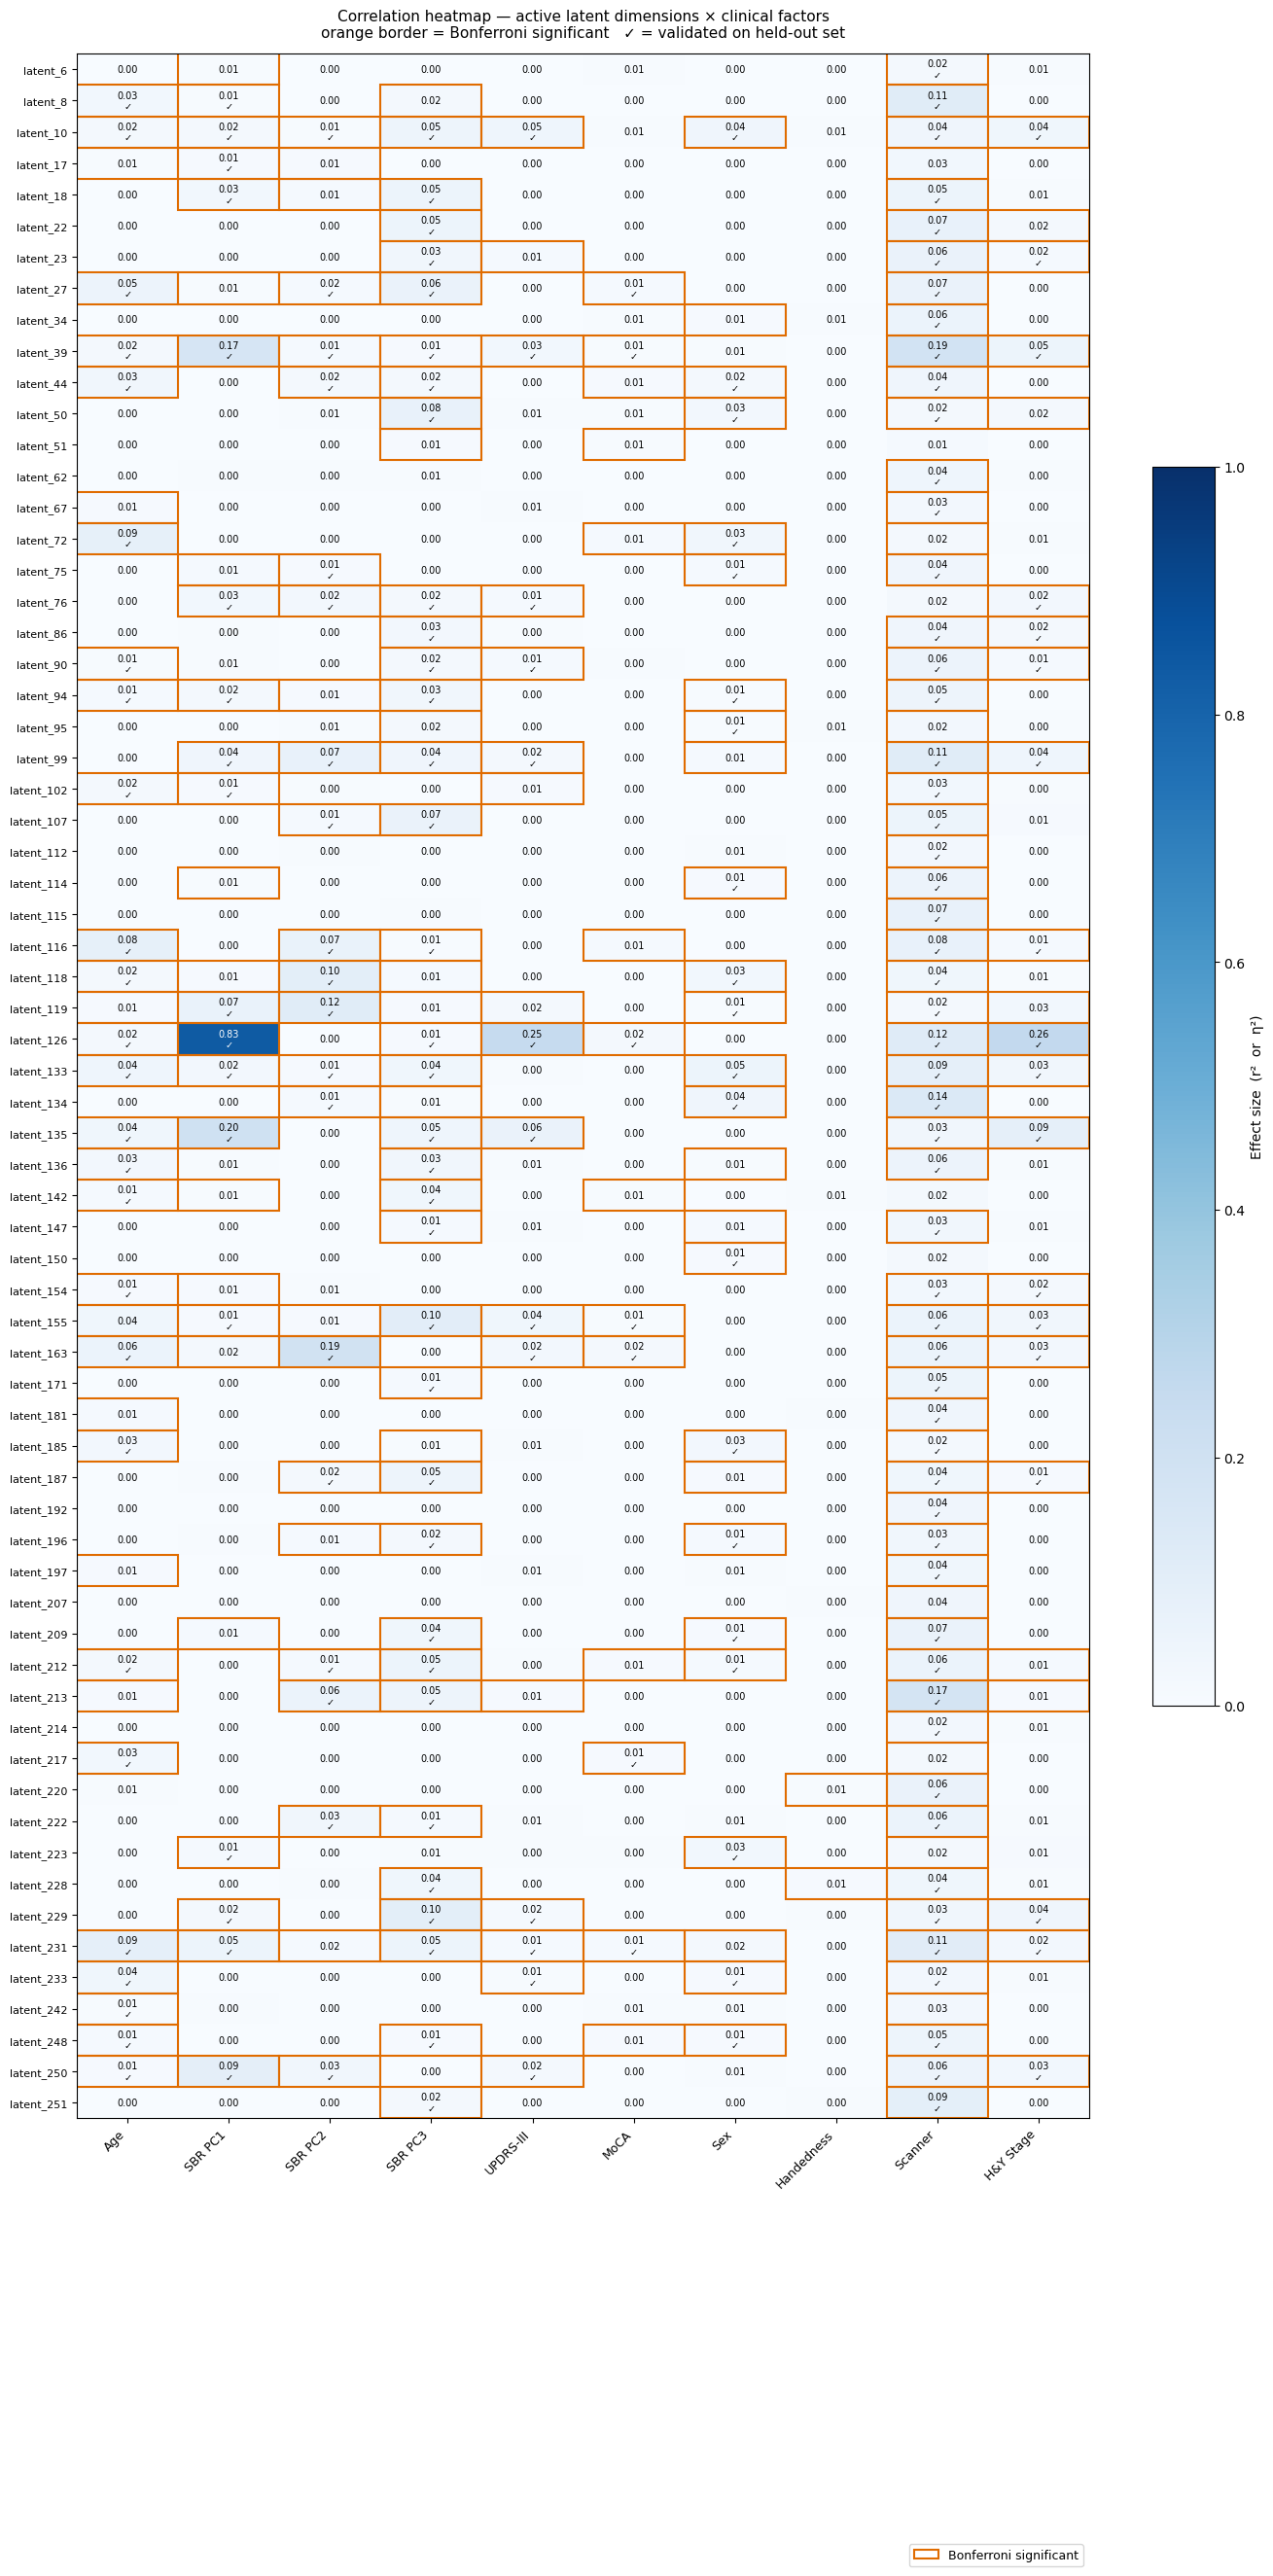

Saved: ../../results/figures/correlation_heatmap.png

Showing 66 significant dimensions out of 66 active


In [32]:
# Only show dimensions significant for at least one factor
sig_any = df_results[[f'{f}_sig' for f in ALL_FACTORS
                       if f'{f}_sig' in df_results.columns]].any(axis=1)
df_sig  = df_results[sig_any].copy()

if len(df_sig) == 0:
    print("No significant dimensions found — check Bonferroni threshold.")
else:
    # Build effect size matrix
    factor_labels = {
        'AGE_AT_VISIT': 'Age', 'SBR_PC1': 'SBR PC1', 'SBR_PC2': 'SBR PC2',
        'SBR_PC3': 'SBR PC3', 'UPDRS1_TOTAL': 'UPDRS-I', 'UPDRS2_TOTAL': 'UPDRS-II',
        'UPDRS3_TOTAL': 'UPDRS-III', 'UPDRS4_TOTAL': 'UPDRS-IV',
        'MOCA_TOTAL': 'MoCA', 'RBD_SCORE': 'RBD',
        'SEX': 'Sex', 'HANDED': 'Handedness',
        'Manufacturer': 'Scanner', 'HOEHN_YAHR': 'H&Y Stage'
    }

    dims_to_show = df_sig['dimension'].tolist()
    factors_available = [f for f in ALL_FACTORS
                         if f'{f}_sig' in df_results.columns]

    effect_matrix = np.zeros((len(dims_to_show), len(factors_available)))
    sig_matrix    = np.zeros((len(dims_to_show), len(factors_available)), dtype=bool)
    val_matrix    = np.zeros((len(dims_to_show), len(factors_available)), dtype=bool)

    for i, dim in enumerate(dims_to_show):
        t_row = df_results[df_results['dimension'] == dim].iloc[0]
        v_row = df_validated[df_validated['dimension'] == dim].iloc[0]
        for j, factor in enumerate(factors_available):
            if factor in CONTINUOUS_FACTORS:
                effect_matrix[i, j] = t_row.get(f'{factor}_r2', 0) or 0
            else:
                effect_matrix[i, j] = t_row.get(f'{factor}_eta2', 0) or 0
            sig_matrix[i, j] = bool(t_row.get(f'{factor}_sig', False))
            val_matrix[i, j] = bool(v_row.get(f'{factor}_validated', False))

    fig, ax = plt.subplots(figsize=(14, max(6, len(dims_to_show) * 0.4)))
    im = ax.imshow(effect_matrix, cmap='Blues', vmin=0, vmax=1, aspect='auto')

    xlabels = [factor_labels.get(f, f) for f in factors_available]
    ax.set_xticks(range(len(factors_available)))
    ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(dims_to_show)))
    ax.set_yticklabels(dims_to_show, fontsize=8)
    ax.set_title(
        'Correlation heatmap — active latent dimensions × clinical factors\n'
        'orange border = Bonferroni significant   ✓ = validated on held-out set',
        fontsize=11, pad=12
    )

    for i in range(len(dims_to_show)):
        for j in range(len(factors_available)):
            v = effect_matrix[i, j]
            if sig_matrix[i, j]:
                ax.add_patch(plt.Rectangle(
                    [j-0.5, i-0.5], 1, 1,
                    fill=False, edgecolor='#e06c00', linewidth=1.5
                ))
            label = f'{v:.2f}' + ('\n✓' if val_matrix[i, j] else '')
            ax.text(j, i, label, ha='center', va='center',
                    fontsize=7, color='white' if v > 0.5 else 'black')

    plt.colorbar(im, ax=ax, label='Effect size  (r²  or  η²)', shrink=0.6)
    ax.legend(
        handles=[mpatches.Patch(fill=False, edgecolor='#e06c00',
                 linewidth=1.5, label='Bonferroni significant')],
        loc='lower right', bbox_to_anchor=(1.0, -0.22), fontsize=9
    )
    plt.tight_layout()
    path = f'{FIGURES_DIR}/correlation_heatmap.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")
    print(f"\nShowing {len(dims_to_show)} significant dimensions out of {len(active_dims)} active")

## 9. ANCOVA Scatter Plot

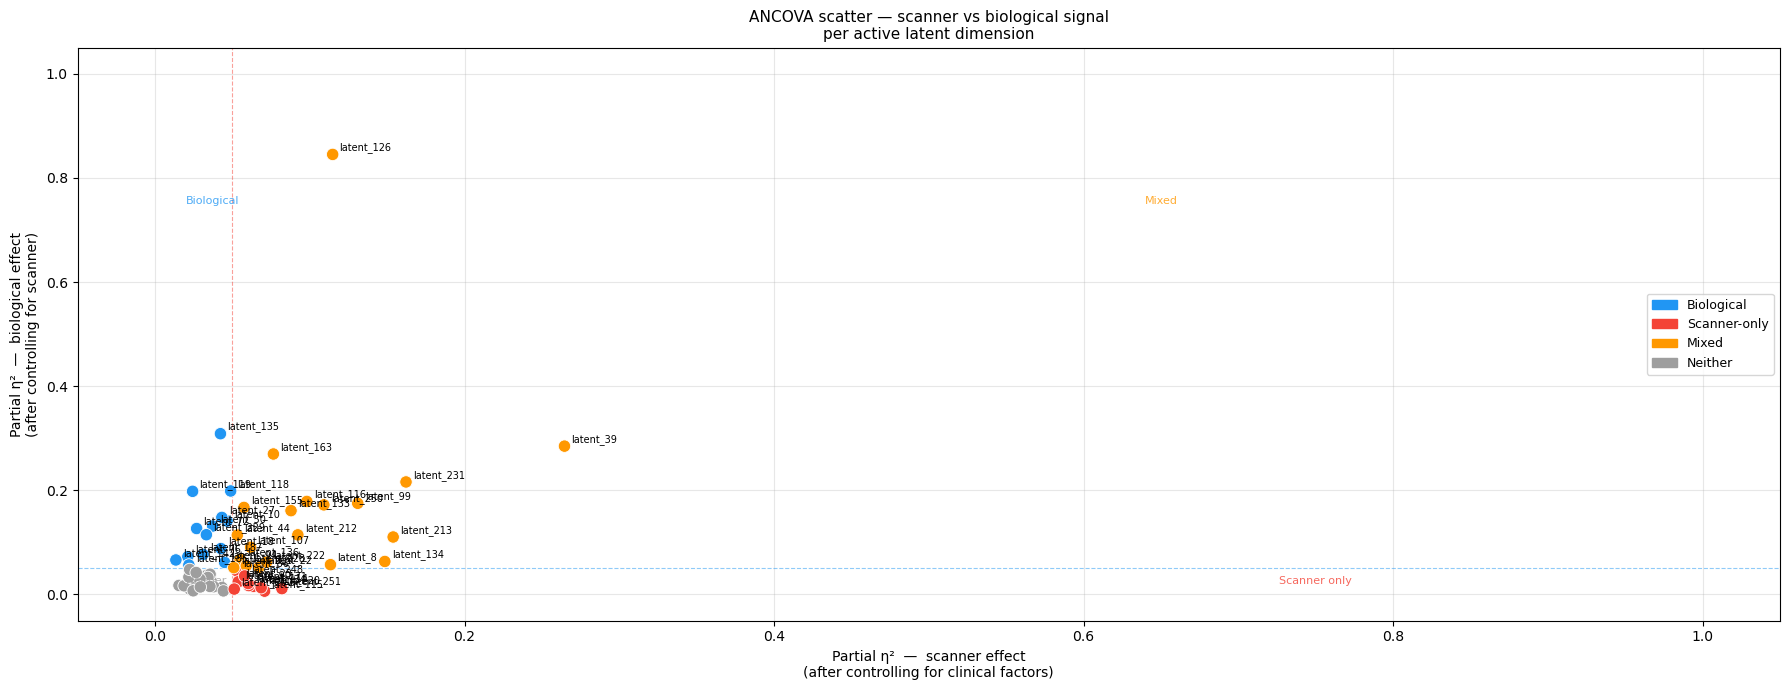

Saved: ../../results/figures/ancova_scatter.png


In [33]:
df_anc = df_ancova.dropna(subset=['peta2_scanner', 'peta2_biological'])

color_map = {
    'Biological':   '#2196F3',
    'Scanner-only': '#F44336',
    'Mixed':        '#FF9800',
    'Neither':      '#9E9E9E',
}
colors = [color_map.get(c, '#9E9E9E') for c in df_anc['category']]

fig, ax = plt.subplots(figsize=(18, 7))
ax.scatter(df_anc['peta2_scanner'], df_anc['peta2_biological'],
           c=colors, s=80, edgecolors='white', linewidths=0.6, zorder=3)

for _, row in df_anc.iterrows():
    if row['peta2_scanner'] > 0.05 or row['peta2_biological'] > 0.05:
        ax.annotate(row['dimension'],
                    (row['peta2_scanner'], row['peta2_biological']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)

ax.axvline(0.05, color='#F44336', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(0.05, color='#2196F3', linestyle='--', linewidth=0.8, alpha=0.5)

ax.text(0.75, 0.02, 'Scanner only',  ha='center', fontsize=8, color='#F44336', alpha=0.8)
ax.text(0.02, 0.75, 'Biological',    ha='left',   fontsize=8, color='#2196F3', alpha=0.8)
ax.text(0.65, 0.75, 'Mixed',         ha='center', fontsize=8, color='#FF9800', alpha=0.8)
ax.text(0.02, 0.02, 'Neither',       ha='left',   fontsize=8, color='#9E9E9E', alpha=0.8)

ax.set_xlabel('Partial η²  —  scanner effect\n(after controlling for clinical factors)', fontsize=10)
ax.set_ylabel('Partial η²  —  biological effect\n(after controlling for scanner)', fontsize=10)
ax.set_title('ANCOVA scatter — scanner vs biological signal\nper active latent dimension', fontsize=11)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(
    handles=[mpatches.Patch(color=v, label=k) for k, v in color_map.items()],
    fontsize=9, loc='center right', bbox_to_anchor=(1.0, 0.5)
)
plt.tight_layout()
path = f'{FIGURES_DIR}/ancova_scatter.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")

In [34]:
EFFECT_THRESHOLD = 0.05  # minimum partial eta2 to call an effect "meaningful"

def reclassify(row):
    sig_bio     = row['peta2_biological'] > EFFECT_THRESHOLD
    sig_scanner = row['peta2_scanner']    > EFFECT_THRESHOLD
    if   sig_bio and not sig_scanner: return 'Biological'
    elif sig_scanner and not sig_bio: return 'Scanner-only'
    elif sig_bio and sig_scanner:     return 'Mixed'
    else:                             return 'Neither'

df_ancova['category'] = df_ancova.apply(reclassify, axis=1)

print(" Corrected ANCOVA categories ")
print(df_ancova['category'].value_counts().to_string())

safe_dims    = df_ancova[df_ancova['category'] == 'Biological']['dimension'].tolist()
scanner_dims = df_ancova[df_ancova['category'] == 'Scanner-only']['dimension'].tolist()
mixed_dims   = df_ancova[df_ancova['category'] == 'Mixed']['dimension'].tolist()

print(f"\nBiological dims: {safe_dims}")
print(f"Scanner-only:    {scanner_dims}")
print(f"Mixed:           {mixed_dims}")

 Corrected ANCOVA categories 
category
Neither         21
Mixed           20
Biological      14
Scanner-only    11

Biological dims: ['latent_10', 'latent_18', 'latent_27', 'latent_50', 'latent_72', 'latent_76', 'latent_94', 'latent_118', 'latent_119', 'latent_135', 'latent_142', 'latent_185', 'latent_187', 'latent_229']
Scanner-only:    ['latent_23', 'latent_34', 'latent_86', 'latent_90', 'latent_114', 'latent_115', 'latent_171', 'latent_207', 'latent_220', 'latent_248', 'latent_251']
Mixed:           ['latent_8', 'latent_22', 'latent_39', 'latent_44', 'latent_99', 'latent_107', 'latent_116', 'latent_126', 'latent_133', 'latent_134', 'latent_136', 'latent_155', 'latent_163', 'latent_209', 'latent_212', 'latent_213', 'latent_222', 'latent_228', 'latent_231', 'latent_250']


## 10. Summary

In [35]:
print("=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nDataset:")
print(f"  Train: {len(df_train)} rows, {df_train[PATIENT_COL].nunique()} patients")
print(f"  Val:   {len(df_val)} rows,   {df_val[PATIENT_COL].nunique()} patients")
print(f"  Patient overlap: 0 ✓")

print(f"\nLatent space:")
print(f"  Active dimensions: {len(active_dims)} / {len(LATENT_COLS)}")
print(f"  Collapse rate:     {len(collapsed_dims)/len(LATENT_COLS)*100:.1f}%")

print(f"\nBonferroni threshold: p < {alpha_bonf:.6f}")

print(f"\nSignificant findings (Bonferroni corrected):")
for factor in ALL_FACTORS:
    col = f'{factor}_sig'
    if col in df_results.columns:
        n_sig = int(df_results[col].sum())
        col_v = f'{factor}_validated'
        n_val = int(df_validated[col_v].sum()) if col_v in df_validated.columns else 0
        if n_sig > 0:
            print(f"  {factor:<25} {n_sig:>3} significant, {n_val:>3} validated")

print(f"\nANCOVA classification:")
print(df_ancova['category'].value_counts().to_string())

print(f"\nOutputs saved to:")
print(f"  {OUTPUT_DIR}/correlation_train.csv")
print(f"  {OUTPUT_DIR}/correlation_val.csv")
print(f"  {OUTPUT_DIR}/ancova_results.csv")
print(f"  {FIGURES_DIR}/correlation_heatmap.png")
print(f"  {FIGURES_DIR}/ancova_scatter.png")

ANALYSIS SUMMARY

Dataset:
  Train: 1894 rows, 1148 patients
  Val:   479 rows,   289 patients
  Patient overlap: 0 ✓

Latent space:
  Active dimensions: 66 / 256
  Collapse rate:     74.2%

Bonferroni threshold: p < 0.000758

Significant findings (Bonferroni corrected):
  AGE_AT_VISIT               33 significant,  26 validated
  SBR_PC1                    27 significant,  18 validated
  SBR_PC2                    25 significant,  19 validated
  SBR_PC3                    41 significant,  34 validated
  UPDRS3_TOTAL               17 significant,  13 validated
  MOCA_TOTAL                 14 significant,   7 validated
  SEX                        26 significant,  20 validated
  HANDED                      2 significant,   0 validated
  Manufacturer               62 significant,  55 validated
  HOEHN_YAHR                 23 significant,  18 validated

ANCOVA classification:
category
Neither         21
Mixed           20
Biological      14
Scanner-only    11

Outputs saved to:
  ../../re